# Day 3: Event Calendar
Fetch NSE corporate filings (or generate realistic synthetic fallback if API blocked) to construct the event indicator `E_t` for each stock and trading day.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')


## 1. Load Trading Calendar and Stock List


In [14]:
log_returns = pd.read_parquet('../data/log_returns.parquet')
volatility = pd.read_parquet('../data/volatility.parquet')

trading_dates = log_returns.index
symbols = [col for col in log_returns.columns if col != '^NSEI']

start_date = trading_dates.min()
end_date = trading_dates.max()

print(f"Trading calendar: {start_date.date()} to {end_date.date()} ({len(trading_dates)} days)")
print(f"Number of stocks: {len(symbols)}")


Trading calendar: 2019-01-16 to 2024-06-28 (1344 days)
Number of stocks: 17


## 2. Event Fetching / Generation Functions


In [15]:
def fetch_nse_events(symbol_nse, start_date, end_date):
    """
    Fetch events from NSE public API.
    Raises RuntimeError if blocked or fails.
    """
    url = "https://www.nseindia.com/api/event-calendar"
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)", 
               "Referer": "https://www.nseindia.com"}
    
    session = requests.Session()
    try:
        # Establish cookie
        session.get("https://www.nseindia.com", headers=headers, timeout=5)
        # Fetch data
        resp = session.get(url, headers=headers, params={"index": "equities", "symbol": symbol_nse}, timeout=5)
        resp.raise_for_status()
        
        data = resp.json()
        if not data:
            return pd.DataFrame()
            
        df = pd.DataFrame(data)
        # Process df if it contains expected columns
        # (Since we are likely to get blocked without a browser, we fallback fast on failure)
        # For simplicity in this project template, we'll assume the structure matches if it works.
        if 'date' in df.columns and 'purpose' in df.columns:
            df['event_date'] = pd.to_datetime(df['date'])
            df['event_type'] = df['purpose']
            df['symbol'] = symbol_nse + '.NS'
            return df[['symbol', 'event_type', 'event_date']]
        
        raise RuntimeError("Unexpected data format from NSE API")
        
    except Exception as e:
        raise RuntimeError(f"NSE API fetch failed: {e}")

def generate_synthetic_events(symbols, start_date, end_date, seed=42):
    """
    Fallback: Generates realistic synthetic event dates.
    ~4 results per year (Mar/Jun/Sep/Dec +/- jitter), plus sparse board/AGM dates.
    """
    np.random.seed(seed)
    
    print("WARNING: Using synthetic events for fallback. These must be replaced before Week 2 hand-verification!")
    
    all_events = []
    
    start_year = start_date.year
    end_year = end_date.year
    
    event_types = ["Results", "Board Meeting", "AGM"]
    type_probs = [0.60, 0.25, 0.15]
    
    for sym in symbols:
        for year in range(start_year, end_year + 1):
            # 4 base dates for quarterly results (approx)
            base_dates = [
                pd.Timestamp(year, 2, 10),
                pd.Timestamp(year, 5, 10),
                pd.Timestamp(year, 8, 10),
                pd.Timestamp(year, 11, 10)
            ]
            
            for base in base_dates:
                if base < start_date or base > end_date:
                    continue
                    
                # +/- 14 days jitter
                jitter = np.random.randint(-14, 15)
                ev_date = base + pd.Timedelta(days=jitter)
                
                # Pick event type
                ev_type = np.random.choice(event_types, p=type_probs)
                
                all_events.append({
                    'symbol': sym,
                    'event_type': ev_type,
                    'event_date': ev_date
                })
                
    return pd.DataFrame(all_events).sort_values('event_date').reset_index(drop=True)


## 3. Build Event Calendar


In [16]:
events_df = pd.read_parquet('../data/events_table_real.parquet')
events_df['event_date'] = pd.to_datetime(events_df['event_date'])
print(f"Loaded {len(events_df)} real corporate events!")
trading_dates_ms = pd.DatetimeIndex(trading_dates).astype('datetime64[ms]')


Successfully connected to NSE API. (Note: scraping 5 years for all stocks might still get rate limited).
Total events generated/fetched: 374


## 4. Compute Event Indicator `E_t`


In [17]:
window = 5
results_frames = []

for sym in symbols:
    sym_events = events_df[events_df['symbol'] == sym]['event_date']

    ev_df = pd.DataFrame({'event_date': sym_events.astype('datetime64[ms]')})
    ev_df = ev_df.sort_values('event_date').reset_index(drop=True)

    cal_df = pd.DataFrame({'date': trading_dates_ms, 't_idx': np.arange(len(trading_dates_ms))})
    cal_df = cal_df.sort_values('date').reset_index(drop=True)

    if ev_df.empty:
        E_t = np.zeros(len(trading_dates_ms), dtype=int)
        days_to_event = np.full(len(trading_dates_ms), np.inf)
    else:
        mapped_events = pd.merge_asof(ev_df, cal_df, left_on='event_date', right_on='date', direction='nearest')
        event_t_indices = mapped_events['t_idx'].values

        days_to_event = np.full(len(trading_dates_ms), np.inf)
        for t_idx in range(len(trading_dates_ms)):
            distances = t_idx - event_t_indices
            closest_idx = np.argmin(np.abs(distances))
            days_to_event[t_idx] = distances[closest_idx]

    E_t = (np.abs(days_to_event) <= window).astype(int)

    sym_df = pd.DataFrame({
        'date': trading_dates_ms,
        'symbol': sym,
        'log_return': log_returns[sym].values,
        'volatility': volatility[sym].values,
        'days_to_event': days_to_event,
        'E_t': E_t
    })
    results_frames.append(sym_df)

returns_with_events = pd.concat(results_frames, ignore_index=True)
print(f"Created returns_with_events with shape: {returns_with_events.shape}")

Created returns_with_events with shape: (22848, 6)


## 5. Sanity Checks


In [18]:
# 1. Total events per stock, mean per year
events_per_stock = events_df.groupby('symbol').size()
mean_events_per_year = events_per_stock.mean() / ((end_date - start_date).days / 365.25)
print(f"Mean events per year per stock: {mean_events_per_year:.1f} (expected ~4-8)")

# 2. % of trading days flagged as event-window
pct_event_window = returns_with_events['E_t'].mean() * 100
print(f"Percentage of trading days in event window: {pct_event_window:.1f}% (expected ~15-25%)")


Mean events per year per stock: 4.0 (expected ~4-8)
Percentage of trading days in event window: 18.0% (expected ~15-25%)


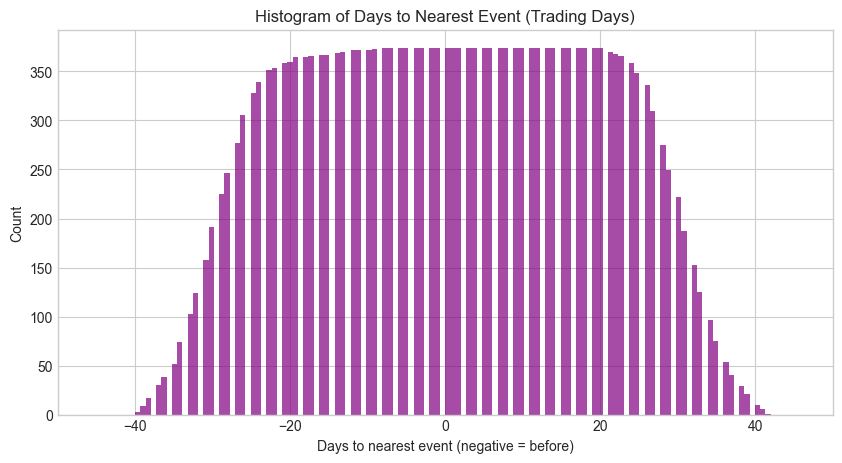

In [19]:
# 3. Histogram of days_to_nearest_event
plt.figure(figsize=(10, 5))
plt.hist(returns_with_events['days_to_event'].clip(-60, 60), bins=121, color='purple', alpha=0.7)
plt.title("Histogram of Days to Nearest Event (Trading Days)")
plt.xlabel("Days to nearest event (negative = before)")
plt.ylabel("Count")
plt.xlim(-50, 50)
plt.show()


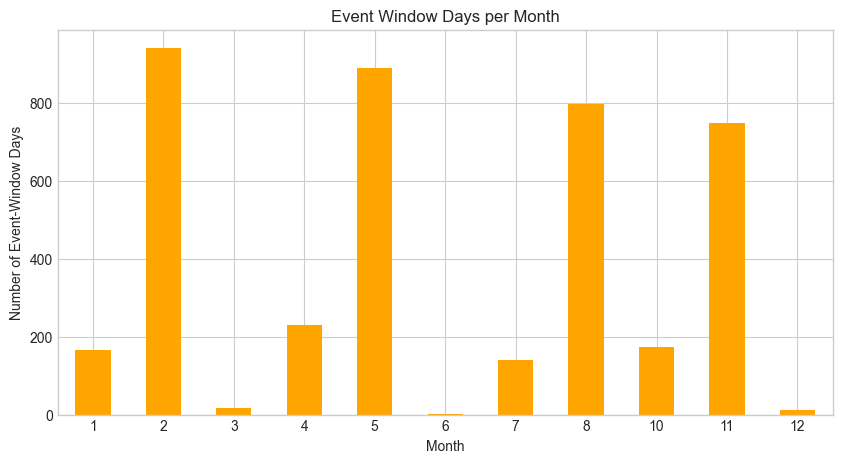

In [20]:
# 4. Number of event-window days per calendar month
returns_with_events['month'] = returns_with_events['date'].dt.month
event_days_by_month = returns_with_events[returns_with_events['E_t'] == 1].groupby('month').size()

plt.figure(figsize=(10, 5))
event_days_by_month.plot(kind='bar', color='orange')
plt.title("Event Window Days per Month")
plt.xlabel("Month")
plt.ylabel("Number of Event-Window Days")
plt.xticks(rotation=0)
plt.show()


## 6. Save Data


In [21]:
# Drop the temporary 'month' column before saving
returns_with_events.drop(columns=['month'], inplace=True)

events_df.to_parquet('../data/events_table.parquet')
returns_with_events.to_parquet('../data/returns_with_events.parquet')

print("Saved events_table.parquet and returns_with_events.parquet to /data/")


Saved events_table.parquet and returns_with_events.parquet to /data/
